In [2]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
Keras version: 3.13.2
GPU available: False


In [5]:
# ===================== SUMMARY =====================
# This code:
# 1. Imports required libraries (NumPy, Pandas, Math)
# 2. Configures Pandas display settings for better readability
# 3. Uploads a CSV file in Google Colab
# 4. Reads the car dataset into a DataFrame
# 5. Defines column (feature) names for the dataset
# 6. Reloads the dataset with proper column headers
# 7. Displays the first 2 rows of the dataset
# ===================================================


# Import necessary libraries for data handling and numerical operations
import numpy as np
import pandas as pd
import math


# Configure pandas display settings:
# - Show floats with 1 decimal place
# - Limit output to 15 rows for readability
pd.options.display.float_format = '{:.1f}'.format
pd.options.display.max_rows = 15


# Upload file manually in Google Colab environment
from google.colab import files
upload = files.upload()


# Initial read of dataset (without column names)
car_data = pd.read_csv("cars_data.csv")


# Define column names based on dataset documentation
feature_names = ['symboling', 'normalized-losses', 'make', 'fuel-type',
        'aspiration', 'num-doors', 'body-style', 'drive-wheels',
        'engine-location', 'wheel-base', 'length', 'width', 'height', 'weight',
        'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore',
        'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
        'highway-mpg', 'price']



# Reload dataset with proper column names and encoding
car_data = pd.read_csv(
    "cars_data.csv",
    names=feature_names,
    header=None,
    encoding='latin-1'
)


# Display first 2 rows to verify data structure
car_data.head(2)

Saving cars_data.csv to cars_data (1).csv


,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500


In [3]:
# Shuffle the dataset randomly to avoid any ordering bias
#car_data = car_data.reindex(np.random.permutation(car_data.index))
car_data = car_data.sample(frac=1, random_state=42)


# Print total number of instances (rows) in the dataset
print(" Instances of car prices and details loaded:  ", len(car_data))


# Display first 10 rows of the shuffled dataset
car_data.head(10)

 Instances of car prices and details loaded:   205


,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
15,0,?,bmw,gas,std,four,sedan,rwd,front,103.5,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,30760
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?
100,0,106,nissan,gas,std,four,sedan,fwd,front,97.2,...,120,2bbl,3.33,3.47,8.5,97,5200,27,34,9549
132,3,150,saab,gas,std,two,hatchback,fwd,front,99.1,...,121,mpfi,3.54,3.07,9.3,110,5250,21,28,11850
68,-1,93,mercedes-benz,diesel,turbo,four,wagon,rwd,front,110.0,...,183,idi,3.58,3.64,21.5,123,4350,22,25,28248
95,1,128,nissan,gas,std,two,hatchback,fwd,front,94.5,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,7799
159,0,91,toyota,diesel,std,four,hatchback,fwd,front,95.7,...,110,idi,3.27,3.35,22.5,56,4500,38,47,7788
162,0,91,toyota,gas,std,four,sedan,fwd,front,95.7,...,98,2bbl,3.19,3.03,9.0,70,4800,28,34,9258
147,0,89,subaru,gas,std,four,wagon,fwd,front,97.0,...,108,mpfi,3.62,2.64,9.0,94,5200,25,31,10198
182,2,122,volkswagen,diesel,std,two,sedan,fwd,front,97.3,...,97,idi,3.01,3.40,23.0,52,4800,37,46,7775


In [23]:
from os import PRIO_PROCESS
# Define the target variable (what we want to predict)



car_data.columns = feature_names
LABEL = 'price'


# Select numeric feature columns from the dataset
numeric_feature_names = car_data[['symboling', 'normalized-losses', 'wheel-base',
        'length', 'width', 'height', 'weight', 'engine-size', 'horsepower',
        'peak-rpm', 'city-mpg', 'highway-mpg', 'bore', 'stroke',
         'compression-ratio']].columns.tolist()



# Convert selected numeric columns (and target) to numeric type; invalid values become NaN
for col in numeric_feature_names + [LABEL]:
    car_data[col] = pd.to_numeric(car_data[col], errors='coerce')

# Fill missing numeric values with 0 for a simple baseline
# try to change it filling mean of the missing data instead
car_data = car_data.fillna(0)



# Identify categorical features by removing numeric features and label from all features
categorical_feature_names = list(set(feature_names) - set(numeric_feature_names) - set([LABEL]))


# Print number of numeric features
print(len(numeric_feature_names))


# Validate expected counts of numeric and categorical features
assert len(numeric_feature_names) == 15
assert len(categorical_feature_names) == 10


15


In [24]:
# Step 1.3: Split the dataset into training, validation, and test sets (60/20/20)
# Split the shuffled dataset into three parts to enable objective model evaluation.
#
# Original lab used ALL data for both training and evaluation, which
# causes overfitting and overoptimistic performance estimates. This 3-way split
# is REQUIRED for valid model comparison.



SEED = 42
from sklearn.model_selection import train_test_split

# First split: separate 20% of the data for testing
train_df, test_df = train_test_split(car_data, test_size=0.20, random_state=SEED)

# Second split: take 25% of the remaining data as validation (25% of 80% ≈ 20%)
train_df, val_df  = train_test_split(train_df, test_size=0.25, random_state=SEED)

print(f"Train/Val/Test sizes: {len(train_df)} / {len(val_df)} / {len(test_df)}")




Train/Val/Test sizes: 123 / 41 / 41


In [25]:
# Step 1.4: Define helpful  functions to prepare input data for all tasks.
# Purpose: These functions return numeric-only, categorical-only, or combined inputs
# can write functions to normalise or standarise , encoded etc...
# for direct compatibility with Keras.

TARGET = LABEL

def xy_numeric(df_):
    """Return numeric features (X) and target (y) as NumPy arrays."""
    X = df_[numeric_feature_names].astype('float32').values
    y = df_[TARGET].astype('float32').values
    return X, y

def xy_categorical_dict(df_):
    """Return categorical features as string tensors (dict) and target (y)."""
    X = {c: df_[c].astype(str).values for c in categorical_feature_names}  #type unification for StringLookup
    y = df_[TARGET].astype('float32').values
    return X, y

def xy_all(df_):
    """Return combined numeric and categorical features (X) and target (y)."""
    X = {'numeric': df_[numeric_feature_names].astype('float32').values}
    for c in categorical_feature_names:
        X[c] = df_[c].astype(str).values
    y = df_[TARGET].astype('float32').values
    return X, y

print(" Functions that customise the data are ready .")


 Functions that customise the data are ready .


Task 1:  Baseline Models(no normalization)
Purpose: Establish performance benchmarks with simplest possible models
These baselines provide reference points to measure impact of:

Adding model complexity (linear → MLP)
Adding normalization (Step 3)
Adding categorical features
NO normalization  carried out in this step per assignment requirements

In [27]:
# Prepare numeric-only datasets
# Extract numeric feature arrays and target values (price) for training, validation, and testing datasets.
# This prepares the data for baseline models using only numerical inputs.



Xtr, ytr = xy_numeric(train_df)
Xva, yva = xy_numeric(val_df)
Xte, yte = xy_numeric(test_df)

Xtr.shape, Xva.shape, Xte.shape

((123, 15), (41, 15), (41, 15))

In [29]:
# Step 2.2: Linear regression baseline (simplest possible model)
# Purpose: Build a simple linear regression model using only numeric features.
# Architecture: The model has one Dense layer with linear activation to predict car prices.
#               Input(15) → Dense(1, activation='linear') → Output
#
# Why this model?
# - Simplest hypothesis: price = linear combination of features
# - Fast to train, easy to interpret (coefficients show feature importance)
# - Expected to perform poorly because car prices have non-linear relationships
#
# Hyperparameters:
# - Optimizer: Adam(lr=1e-2) — adaptive learning rate handles unnormalized features
#   better than SGD, though still suboptimal without normalization
# - Loss: MSE (mean squared error) — standard for regression
# - Metric: MAE (mean absolute error) — more interpretable than RMSE (in dollars)
# - Epochs: 200 with batch_size=16 — small batches provide noisy but useful gradients
#
# Expected result: High MAE (~4000-5000) due to linear assumption

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

tf.random.set_seed(42)

# Define model
lin = keras.Sequential([
    layers.Input(shape=(Xtr.shape[1],)),
    layers.Dense(1, activation='linear')
])

# Compile model with Adam optimizer (learning rate = 0.01)
lin.compile(optimizer=keras.optimizers.Adam(1e-2),
            loss='mse',      # Standard regression loss
            metrics=['mae']  # Track MAE for easier interpretation
)

# Train model on training set
# Validation MAE monitored but NOT used for early stopping (baseline comparison)
hist_lin = lin.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=200, batch_size=16, verbose=0 # verbose=0 suppresses per-epoch output
)

# Evaluate on validation and test sets
print("Val MAE (Linear):", hist_lin.history['val_mae'][-1])
print("Test MAE (Linear):", lin.evaluate(Xte, yte, verbose=0)[1])



# Analysis: High MAE confirms that linear models are insufficient for this problem

Val MAE (Linear): 4571.3701171875
Test MAE (Linear): 5234.96044921875


In [30]:
#  Small MLP baseline (numeric-only)
# Purpose: Build and train a small Multi-Layer Perceptron (MLP) using only numeric features.
# Architecture: The model includes one hidden Dense layer with ReLU activation to learn nonlinear patterns.
#               Input(15) → Dense(64, relu) → Dense(1, linear)
#
# Why this model?
# - Adds ONE hidden layer with ReLU activation to capture non-linear patterns
# - 64 units chosen as compromise: enough capacity for 15 features, but not so
#   large that it overfits on 123 training samples
# - ReLU activation introduces nonlinearity without vanishing gradients
#
# Hypothesis: MLP should significantly outperform linear model because:
# 1. Car prices have non-linear relationships (e.g., weight² affects fuel efficiency)
# 2. Feature interactions exist (e.g., horsepower × weight determines acceleration)
# 3. Hidden layer learns composite features automatically
#
# Hyperparameters:
# - Hidden units: 64 (rule of thumb: 2-10x number of input features)
# - Activation: ReLU (most common for hidden layers; no saturation issues)
# - Output: Linear activation (regression requires unbounded output range)
# - Optimizer: Adam(lr=1e-2) — same as linear baseline for fair comparison
# - Batch size: 16 — balances gradient noise (exploration) vs stability

tf.random.set_seed(42)

# Define MLP model
mlp = keras.Sequential([
    layers.Input(shape=(Xtr.shape[1],)),
    layers.Dense(64, activation='relu'),   # Hidden layer learns nonlinear features
    layers.Dense(1, activation='linear')   # Output layer for regression
])

# Compile model
mlp.compile(optimizer=keras.optimizers.Adam(1e-2),
            loss='mse', metrics=['mae'])

# Train model
hist_mlp = mlp.fit(Xtr, ytr,
                   validation_data=(Xva, yva),
                   epochs=200, batch_size=16, verbose=0)

# Evaluate on validation and test sets
print("Val MAE (MLP):", hist_mlp.history['val_mae'][-1])
print("Test MAE (MLP):", mlp.evaluate(Xte, yte, verbose=0)[1])


Val MAE (MLP): 2121.2353515625
Test MAE (MLP): 3315.852783203125


Task 2:  Normalization with Keras Normalization Layer
Purpose: Standardize numeric features (Z-score) using statistics computed on the training set only.
Why: Normalization helps stabilize training, improve convergence speed, and reduce MAE.

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 224113280.0000 - mae: 13016.0527 - val_loss: 239489616.0000 - val_mae: 12856.2959
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 224030944.0000 - mae: 13013.2109 - val_loss: 239371392.0000 - val_mae: 12852.5605
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 223912320.0000 - mae: 13009.3115 - val_loss: 239185968.0000 - val_mae: 12847.0156
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 223735376.0000 - mae: 13003.6309 - val_loss: 238914832.0000 - val_mae: 12839.0537
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 223483376.0000 - mae: 12995.6191 - val_loss: 238539152.0000 - val_mae: 12828.0674
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 223139920.0000 - mae: 12984.7109 - val_loss: 238035888.0000 - val_mae: 12813.3945
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 222686752.0000 - mae: 12970.3359 - val_loss: 237383808.0000 - val_mae: 12794.4014
Epoch 8/200
8/8 ━━━━

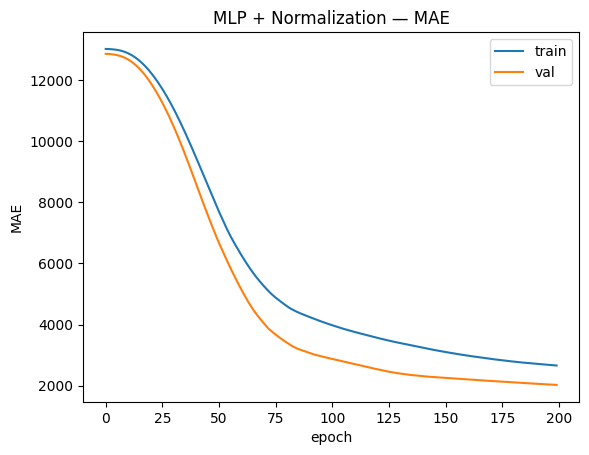

In [31]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Compute normalization statistics from the training set only
mu = train_df[numeric_feature_names].mean().astype('float32').values
sigma = train_df[numeric_feature_names].std().replace(0, 1e-6).astype('float32').values
# Epsilon (1e-6) prevents division by zero for constant features

# Create normalization layer with precomputed statistics
norm = layers.Normalization(mean=mu, variance=(sigma**2))

# Prepare normalized datasets
XtrN = train_df[numeric_feature_names].astype('float32').values
XvaN = val_df[numeric_feature_names].astype('float32').values
XteN = test_df[numeric_feature_names].astype('float32').values
ytrN = train_df[LABEL].astype('float32').values
yvaN = val_df[LABEL].astype('float32').values
yteN = test_df[LABEL].astype('float32').values

# Define MLP model with normalization layer
# Architecture: Input → Normalization → Dense(64, relu) → Dense(1, linear)
#
# Why this architecture?
# - Normalization as first layer ensures all inputs scaled before Dense layer
# - 64 hidden units (same as baseline) for fair comparison
# - ReLU activation enables nonlinear feature learning
#
# Expected impact of normalization:
# 1. Faster convergence (fewer epochs to reach optimal MAE)
# 2. More stable training (less sensitivity to learning rate)
# 3. Lower final MAE (better feature utilization)

tf.random.set_seed(42)

mlp_norm = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    norm,  # Normalization layer applied first
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
])

# Compile and train model with early stopping
# Why EarlyStopping?
# - Small dataset (123 samples) → high risk of memorizing training data
# - Monitor validation MAE; stop if no improvement for 10 epochs
# - Restore best weights (lowest val_mae) for final evaluation

es = keras.callbacks.EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)
mlp_norm.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
hist_norm = mlp_norm.fit(XtrN, ytrN, validation_data=(XvaN, yvaN),
                         epochs=200, batch_size=16, verbose=1, callbacks=[es])

# Evaluate model performance
best_epoch = int(np.argmin(hist_norm.history['val_mae']))
print("Best epoch:", best_epoch + 1)
print("Val MAE (MLP + Norm):", hist_norm.history['val_mae'][best_epoch])
print("Test MAE (MLP + Norm):", mlp_norm.evaluate(XteN, yteN, verbose=0)[1])



# Analysis: Compare this MAE to Step 2.3 baseline. Normalization should yield:
# - Lower final MAE (better feature utilization)
# - Faster convergence (steeper initial drop in training curve)
# - Smaller train-val gap (normalization acts as mild regularization)

Task 2 — Alternative Normalization Approach with Keras Layer

Purpose: This step demonstrates using Keras Normalization layer in a cleaner way
by passing raw float32 arrays and letting the layer handle scaling internally
The layer learns the mean and variance from the training data only, ensuring that validation and test sets remain unbiased.


Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 224126192.0000 - mae: 13016.6250 - val_loss: 239504112.0000 - val_mae: 12857.1553
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 224045168.0000 - mae: 13014.0566 - val_loss: 239401808.0000 - val_mae: 12854.1221
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 223944272.0000 - mae: 13010.9229 - val_loss: 239251200.0000 - val_mae: 12849.7900
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 223797968.0000 - mae: 13006.4307 - val_loss: 239032720.0000 - val_mae: 12843.5430
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 223589776.0000 - mae: 13000.0254 - val_loss: 238725312.0000 - val_mae: 12834.7168
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 223303152.0000 - mae: 12991.1357 - val_loss: 238307632.0000 - val_mae: 12822.6436
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 222920896.0000 - mae: 12979.1924 - val_loss: 237755824.0000 - val_mae: 12806.6650
Epoch 8/200
8/8 ━━━━

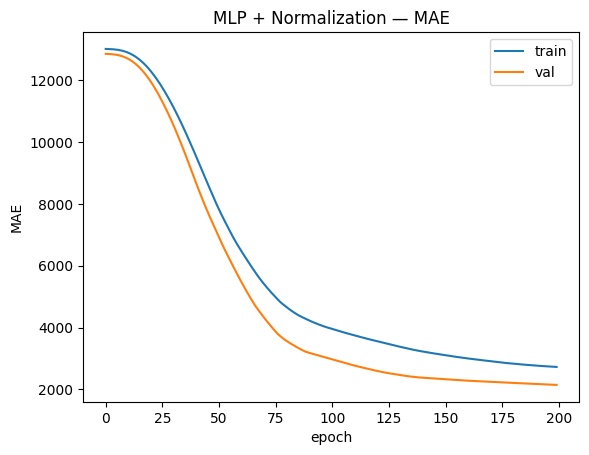

In [33]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)

# Prepare raw numeric arrays (no manual normalization)
XtrN = train_df[numeric_feature_names].astype('float32').values
XvaN = val_df[numeric_feature_names].astype('float32').values
XteN = test_df[numeric_feature_names].astype('float32').values
ytrN = train_df[LABEL].astype('float32').values
yvaN = val_df[LABEL].astype('float32').values
yteN = test_df[LABEL].astype('float32').values

# Define and adapt normalization layer using training data
norm = layers.Normalization()
norm.adapt(XtrN)  # learns mean and variance from training set

# Define the MLP model (Normalization → Dense(64, relu) → Dense(1))
mlp_norm = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    norm,
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
])

# Compile model with Adam optimizer and MSE loss, track MAE metric
mlp_norm.compile(optimizer=keras.optimizers.Adam(1e-2),
                 loss='mse', metrics=['mae'])

# Apply early stopping to prevent overfitting
es = keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=10, restore_best_weights=True
)

# Train model and validate on separate dataset
hist_norm = mlp_norm.fit(
    XtrN, ytrN,
    validation_data=(XvaN, yvaN),
    epochs=200, batch_size=16,
    verbose=1, callbacks=[es]
)

# Evaluate model performance
best_epoch = int(np.argmin(hist_norm.history['val_mae']))
print("Best epoch:", best_epoch + 1)
print("Val MAE (MLP + Norm):", hist_norm.history['val_mae'][best_epoch])
print("Test MAE (MLP + Norm):", mlp_norm.evaluate(XteN, yteN, verbose=0)[1])

# Visualize training dynamics
plt.figure()
plt.plot(hist_norm.history['mae'], label='train')
plt.plot(hist_norm.history['val_mae'], label='val')
plt.title('MLP + Normalization — MAE')
plt.xlabel('epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Analyse: This step helps stabilize learning and improve model convergence.

In [34]:
# Fine-tuning the normalized MLP (deeper architecture with hyperparameter tuning)

# Purpose: Improve upon single-hidden-layer MLP by:
# 1. Adding depth (two hidden layers instead of one)
# 2. Reducing learning rate for smoother convergence
# 3. Using early stopping to prevent overfitting
#
# Architecture: Input → Norm → Dense(128, relu) → Dense(64, relu) → Dense(1)
#
# Why two hidden layers?
# - First layer (128 units): Learns high-level feature combinations
# - Second layer (64 units): Refines these combinations for price prediction
# - Hierarchical representation learning (common in deep learning)
#
# Hyperparameter changes from baseline:
# - Hidden units: [64] → [128, 64] (more capacity for complex patterns)
# - Learning rate: 1e-2 → 1e-3 (smaller steps for deeper network stability)

mlp_norm = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    norm,
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

# Compile the model with a smaller learning rate for smoother convergence
mlp_norm.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])

# Train the model and validate its performance on unseen data
hist_norm = mlp_norm.fit(XtrN, ytrN, validation_data=(XvaN, yvaN),
                         epochs=200, batch_size=16, verbose=1,
                         callbacks=[keras.callbacks.EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)])

# Display validation and test performance
print("Val/Test:", hist_norm.history['val_mae'][np.argmin(hist_norm.history['val_mae'])],
      mlp_norm.evaluate(XteN, yteN, verbose=0)[1])

# Analysis: Compare against single-layer MLP from Step 3/4
# If test MAE is worse despite lower training MAE → overfitting
# This demonstrates the bias-variance tradeoff on small datasets

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 224126656.0000 - mae: 13016.6992 - val_loss: 239539952.0000 - val_mae: 12858.3613
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 224099184.0000 - mae: 13015.8721 - val_loss: 239506080.0000 - val_mae: 12857.4258
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 224066352.0000 - mae: 13014.9092 - val_loss: 239462400.0000 - val_mae: 12856.2363
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 224023456.0000 - mae: 13013.6689 - val_loss: 239403904.0000 - val_mae: 12854.6787
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 223966256.0000 - mae: 13012.0361 - val_loss: 239324336.0000 - val_mae: 12852.6064
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 223889520.0000 - mae: 13009.8848 - val_loss: 239217408.0000 - val_mae: 12849.8770
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 223788384.0000 - mae: 13007.0801 - val_loss: 239076784.0000 - val_mae: 12846.3428
Epoch 8/200
8/8 ━━━━

## Task 3 — Categorical-only model

Purpose: Evaluate predictive power of categorical features independently<br>
This isolates the contribution of nominal attributes like make, fuel-type, etc.

In [36]:
# Purpose: Evaluate predictive power of categorical features independently
# This isolates the contribution of nominal attributes like make, fuel-type, etc.
#
# Why categorical features matter for car prices?
# - 'make': Premium brands (BMW, Mercedes) command higher prices
# - 'fuel-type': Diesel vs gas affects price due to efficiency/demand
# - 'body-style': Convertibles typically more expensive than sedans
#
# Technical approach:
# 1. Use StringLookup layers to convert strings → integer indices
# 2. One-hot encode integers → binary vectors (e.g., [0,0,1,0] for category 3)
# 3. Concatenate all one-hot vectors → feed into MLP
#
# Architecture:
# [make, fuel-type, ...] → [StringLookup+OneHot for each] → Concatenate
# → Dense(128, relu) → Dense(64, relu) → Dense(1)

from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)

# Build Keras Inputs and one-hot encoders for each categorical column
# Each categorical feature is processed through a StringLookup layer
# that converts string categories into one-hot encoded binary vectors.
cat_inputs, cat_onehots = [], []
cat_vocab = {}

for col in categorical_feature_names:
    # Define input layer for this categorical feature
    inp = keras.Input(shape=(1,), dtype='string', name=col)

    # Extract unique values from training set (vocabulary)
    vocab = train_df[col].astype(str).unique().tolist()
    cat_vocab[col] = vocab

    # StringLookup: string → integer index (0=OOV, 1=vocab[0], 2=vocab[1], ...)
    # output_mode='one_hot': converts integer → binary vector automatically
    lookup = layers.StringLookup(vocabulary=vocab, output_mode='one_hot', name=f"{col}_lookup")
    oh = lookup(inp)

    cat_inputs.append(inp)
    cat_onehots.append(oh)

# Concatenate all one-hot vectors and add a small dense regression head
# The MLP consists of two hidden layers with ReLU activation and one linear output neuron.
x = layers.Concatenate(name="cat_concat")(cat_onehots)
x = layers.Dense(128, activation='relu')(x) # Learn feature combinations
x = layers.Dense(64, activation='relu')(x)  # Refine representations
out = layers.Dense(1, name='price')(x)      # Predict price

# Build model using Functional API (required for multiple inputs)
cat_model = keras.Model(inputs=cat_inputs, outputs=out, name="cat_only_onehot")

cat_model.compile(
    optimizer=keras.optimizers.Adagrad(1e-2),
    loss='mse',
    metrics=['mae']
)

# Prepare categorical inputs (convert each feature into string arrays)
def XY_cat(df_):
    X = {c: df_[c].astype(str).values for c in categorical_feature_names}
    y = df_[LABEL].astype('float32').values
    return X, y

XtrC, ytrC = XY_cat(train_df)
XvaC, yvaC = XY_cat(val_df)
XteC, yteC = XY_cat(test_df)

# Train model with early stopping to avoid overfitting
es = keras.callbacks.EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)

hist_cat = cat_model.fit(
    XtrC, ytrC,
    validation_data=(XvaC, yvaC),
    epochs=200, batch_size=16, verbose=1, callbacks=[es]
)

# Evaluate and display performance metrics
best = int(np.argmin(hist_cat.history['val_mae']))
print("Best epoch:", best + 1)
print("Val MAE (Cat-only):", hist_cat.history['val_mae'][best])
print("Test MAE (Cat-only):", cat_model.evaluate(XteC, yteC, verbose=0)[1])


# Analysis: Compare MAE to numeric-only models (Steps 2-4)
# If categorical-only performs reasonably well → confirms that make, fuel-type, etc.
# carry significant price information independent of numeric measurements

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 223920480.0000 - mae: 13008.9707 - val_loss: 238885856.0000 - val_mae: 12831.7344
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 222841936.0000 - mae: 12968.4238 - val_loss: 237309456.0000 - val_mae: 12769.0674
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 220972000.0000 - mae: 12897.5332 - val_loss: 235106304.0000 - val_mae: 12681.1709
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 218549552.0000 - mae: 12805.0449 - val_loss: 232458064.0000 - val_mae: 12574.7168
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 215711360.0000 - mae: 12695.8027 - val_loss: 229448400.0000 - val_mae: 12452.6211
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 212539808.0000 - mae: 12572.4902 - val_loss: 226158640.0000 - val_mae: 12317.7969
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 209109520.0000 - mae: 12437.6719 - val_loss: 222641424.0000 - val_mae: 12172.0488
Epoch 8/200
8/8 ━━━━

## PL comple the last Task